In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
from google.colab import files
files.upload()

!pip install -q kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d meowmeowmeowmeowmeow/gtsrb-german-traffic-sign

!unzip -q gtsrb-german-traffic-sign.zip

In [ ]:
import numpy as np
import os
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sn; sn.set(font_scale=1.4)
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

In [ ]:
data_dir = "/content/traffic_signs"

train_csv = pd.read_csv(os.path.join(data_dir, "Train.csv"))

nb_classes = train_csv["ClassId"].nunique()
print("Number of classes:", nb_classes)

classes = {
    0:'Speed limit (20km/h)', 1:'Speed limit (30km/h)', 2:'Speed limit (50km/h)',
    3:'Speed limit (60km/h)', 4:'Speed limit (70km/h)', 5:'Speed limit (80km/h)',
    6:'End of speed limit (80km/h)', 7:'Speed limit (100km/h)', 8:'Speed limit (120km/h)',
    9:'No passing', 10:'No passing veh over 3.5 tons', 11:'Right-of-way at intersection',
    12:'Priority road', 13:'Yield', 14:'Stop', 15:'No vehicles', 16:'Veh > 3.5 tons prohibited',
    17:'No entry', 18:'General caution', 19:'Dangerous curve left', 20:'Dangerous curve right',
    21:'Double curve', 22:'Bumpy road', 23:'Slippery road', 24:'Road narrows on the right',
    25:'Road work', 26:'Traffic signals', 27:'Pedestrians', 28:'Children crossing',
    29:'Bicycles crossing', 30:'Beware of ice/snow', 31:'Wild animals crossing',
    32:'End speed + passing limits', 33:'Turn right ahead', 34:'Turn left ahead',
    35:'Ahead only', 36:'Go straight or right', 37:'Go straight or left', 38:'Keep right',
    39:'Keep left', 40:'Roundabout mandatory', 41:'End of no passing', 42:'End no passing veh > 3.5 tons'
}

class_names_label = classes

print("Class 2 means:", class_names_label[2])

Number of classes: 43
Class 2 means: Speed limit (50km/h)


In [ ]:
sizes = set()

for i, row in tqdm(train_csv.iterrows(), total=len(train_csv)):
    img_path = os.path.join(data_dir, row["Path"])
    image = cv2.imread(img_path)
    if image is not None:
        sizes.add(image.shape[:2])

print("Unique image sizes in Train:", sizes)
print("Number of unique sizes:", len(sizes))

100%|██████████| 39209/39209 [00:13<00:00, 2848.25it/s]

Unique image sizes in Train: {(107, 95), (59, 55), (118, 104), (70, 64), (89, 77), (136, 158), (29, 32), (48, 45), (40, 41), (100, 92), (92, 88), (63, 61), (148, 168), (41, 42), (73, 74), (33, 38), (52, 51), (44, 47), (104, 98), (116, 72), (194, 220), (74, 75), (93, 88), (106, 107), (85, 84), (55, 61), (136, 135), (96, 99), (88, 95), (47, 57), (107, 108), (147, 144), (99, 104), (59, 68), (118, 117), (158, 190), (70, 77), (170, 164), (77, 85), (69, 81), (148, 145), (100, 105), (113, 124), (140, 141), (92, 101), (132, 137), (110, 118), (81, 91), (125, 134), (51, 68), (95, 111), (114, 124), (47, 34), (59, 45), (76, 97), (96, 112), (136, 148), (128, 144), (40, 31), (140, 118), (69, 94), (62, 55), (121, 141), (41, 32), (54, 51), (81, 68), (33, 28), (44, 37), (144, 124), (51, 45), (43, 41), (103, 92), (95, 88), (74, 65), (66, 61), (36, 38), (55, 51), (28, 34), (96, 89), (47, 47), (88, 85), (128, 121), (136, 125), (107, 98), (99, 94), (118, 107), (58, 62), (157, 184), (77, 75), (50, 58), (69,

In [ ]:
IMAGE_SIZE = (64, 64)
def load_data(df, base_dir):
    images = []
    labels = []

    for i, row in tqdm(df.iterrows(), total=len(df)):
        img_path = os.path.join(base_dir, row["Path"])
        label = row["ClassId"]

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, IMAGE_SIZE)

        # Normalization
        image = image.astype("float32") / 255.0

        images.append(image)
        labels.append(label)

    images = np.array(images, dtype="float32")
    labels = np.array(labels, dtype="int32")
    return images, labels

test_csv  = pd.read_csv(os.path.join(data_dir, "Test.csv"))

train_images, train_labels = load_data(train_csv, data_dir)
test_images, test_labels = load_data(test_csv, data_dir)


100%|██████████| 12630/12630 [00:06<00:00, 1993.06it/s]


In [ ]:
train_images, train_labels = shuffle(train_images, train_labels, random_state=25)

In [ ]:
n_train = train_labels.shape[0]
n_test = test_labels.shape[0]

print("Number of training examples:", n_train)
print("Number of testing examples:", n_test)
print("Each image is of size:", IMAGE_SIZE)

Number of training examples: 39209
Number of testing examples: 12630
Each image is of size: (64, 64)


In [ ]:
train_ids, train_counts = np.unique(train_labels, return_counts=True)
test_ids, test_counts = np.unique(test_labels, return_counts=True)

df = pd.DataFrame({
    'Train': pd.Series(train_counts, index=train_ids),
    'Test': pd.Series(test_counts, index=test_ids)
})
df.index = [classes[i] for i in df.index]


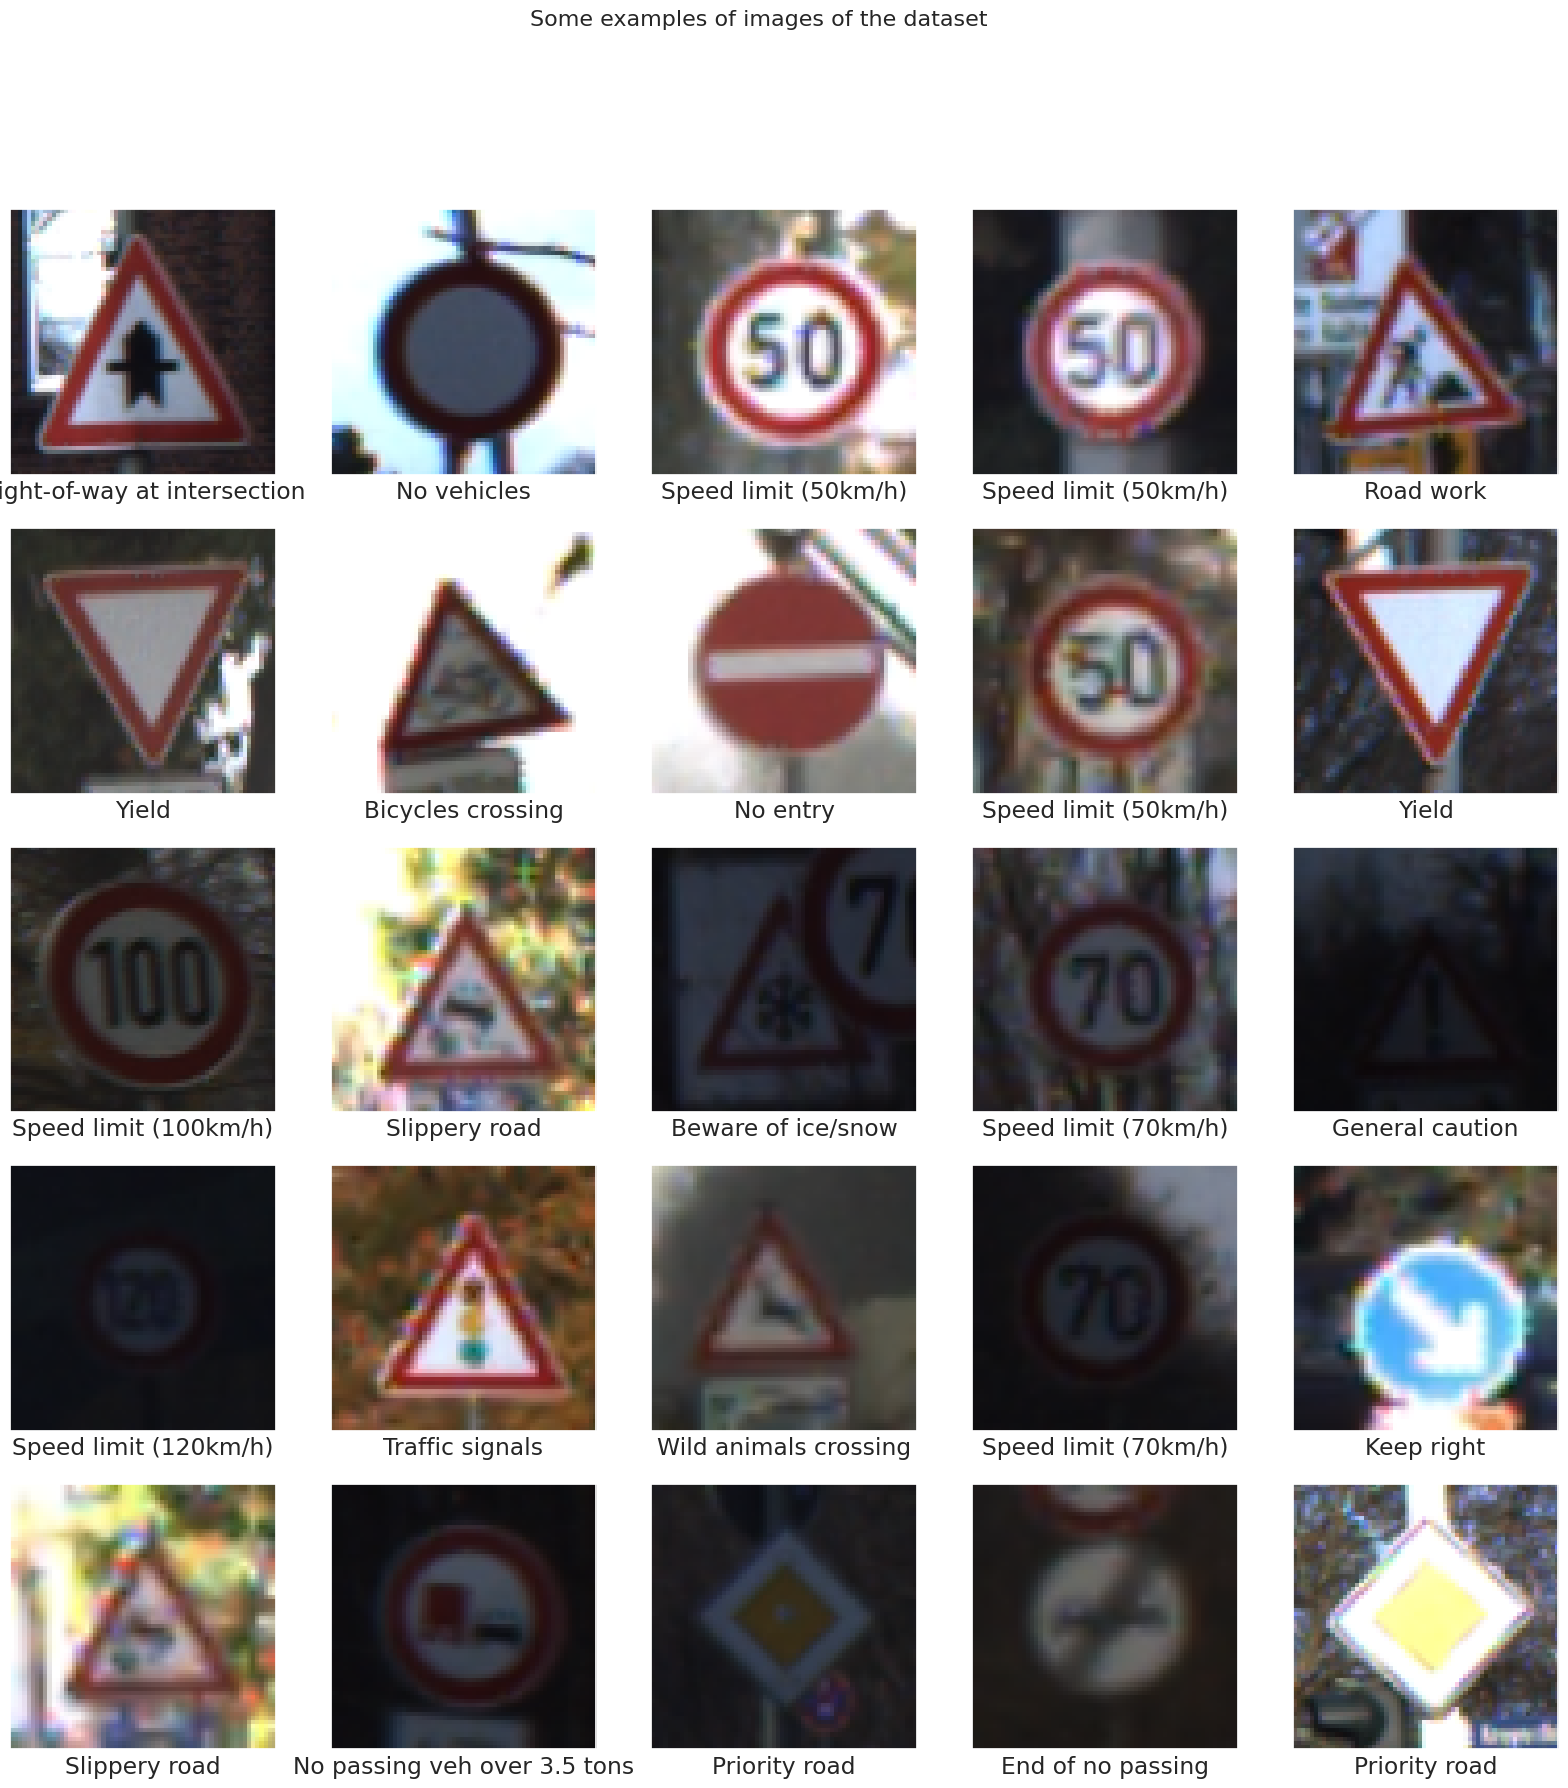

In [ ]:
def display_examples(class_names, images, labels):
    fig = plt.figure(figsize=(20,20))
    fig.suptitle("Some examples of images of the dataset", fontsize=16)
    for i in range(25):
        plt.subplot(5,5,i+1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(images[i])
        plt.xlabel(classes[labels[i]])
    plt.show()

display_examples(classes, train_images, train_labels)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, BatchNormalization

# Building the model
model = Sequential()
model.add(Conv2D(filters=32, kernel_size=(5,5), activation='relu', input_shape=train_images.shape[1:]))
model.add(Conv2D(filters=64, kernel_size=(5,5), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(rate=0.15))
model.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu'))
model.add(Conv2D(filters=256, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(rate=0.20))
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(rate=0.25))
model.add(Dense(43, activation='softmax'))

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 60, 60, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 56, 56, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,874,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        22,059 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,319,659 (73.70 MB)

 Trainable params: 19,319,659 (73.70 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
with tf.device('/GPU:0'):
    epochs = 5
    history1 = model.fit(train_images, train_labels, batch_size=128, epochs=epochs, validation_data=(test_images, test_labels))

Epoch 1/5
307/307 ━━━━━━━━━━━━━━━━━━━━ 2924s 10s/step - accuracy: 0.9777 - loss: 0.0793 - val_accuracy: 0.9575 - val_loss: 0.2081
Epoch 2/5
307/307 ━━━━━━━━━━━━━━━━━━━━ 2935s 10s/step - accuracy: 0.9902 - loss: 0.0341 - val_accuracy: 0.9628 - val_loss: 0.1833
Epoch 3/5
307/307 ━━━━━━━━━━━━━━━━━━━━ 2877s 9s/step - accuracy: 0.9920 - loss: 0.0253 - val_accuracy: 0.9633 - val_loss: 0.1727
Epoch 4/5
307/307 ━━━━━━━━━━━━━━━━━━━━ 2957s 10s/step - accuracy: 0.9951 - loss: 0.0171 - val_accuracy: 0.9675 - val_loss: 0.1859
Epoch 5/5
307/307 ━━━━━━━━━━━━━━━━━━━━ 2933s 9s/step - accuracy: 0.9946 - loss: 0.0168 - val_accuracy: 0.9587 - val_loss: 0.1736


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step


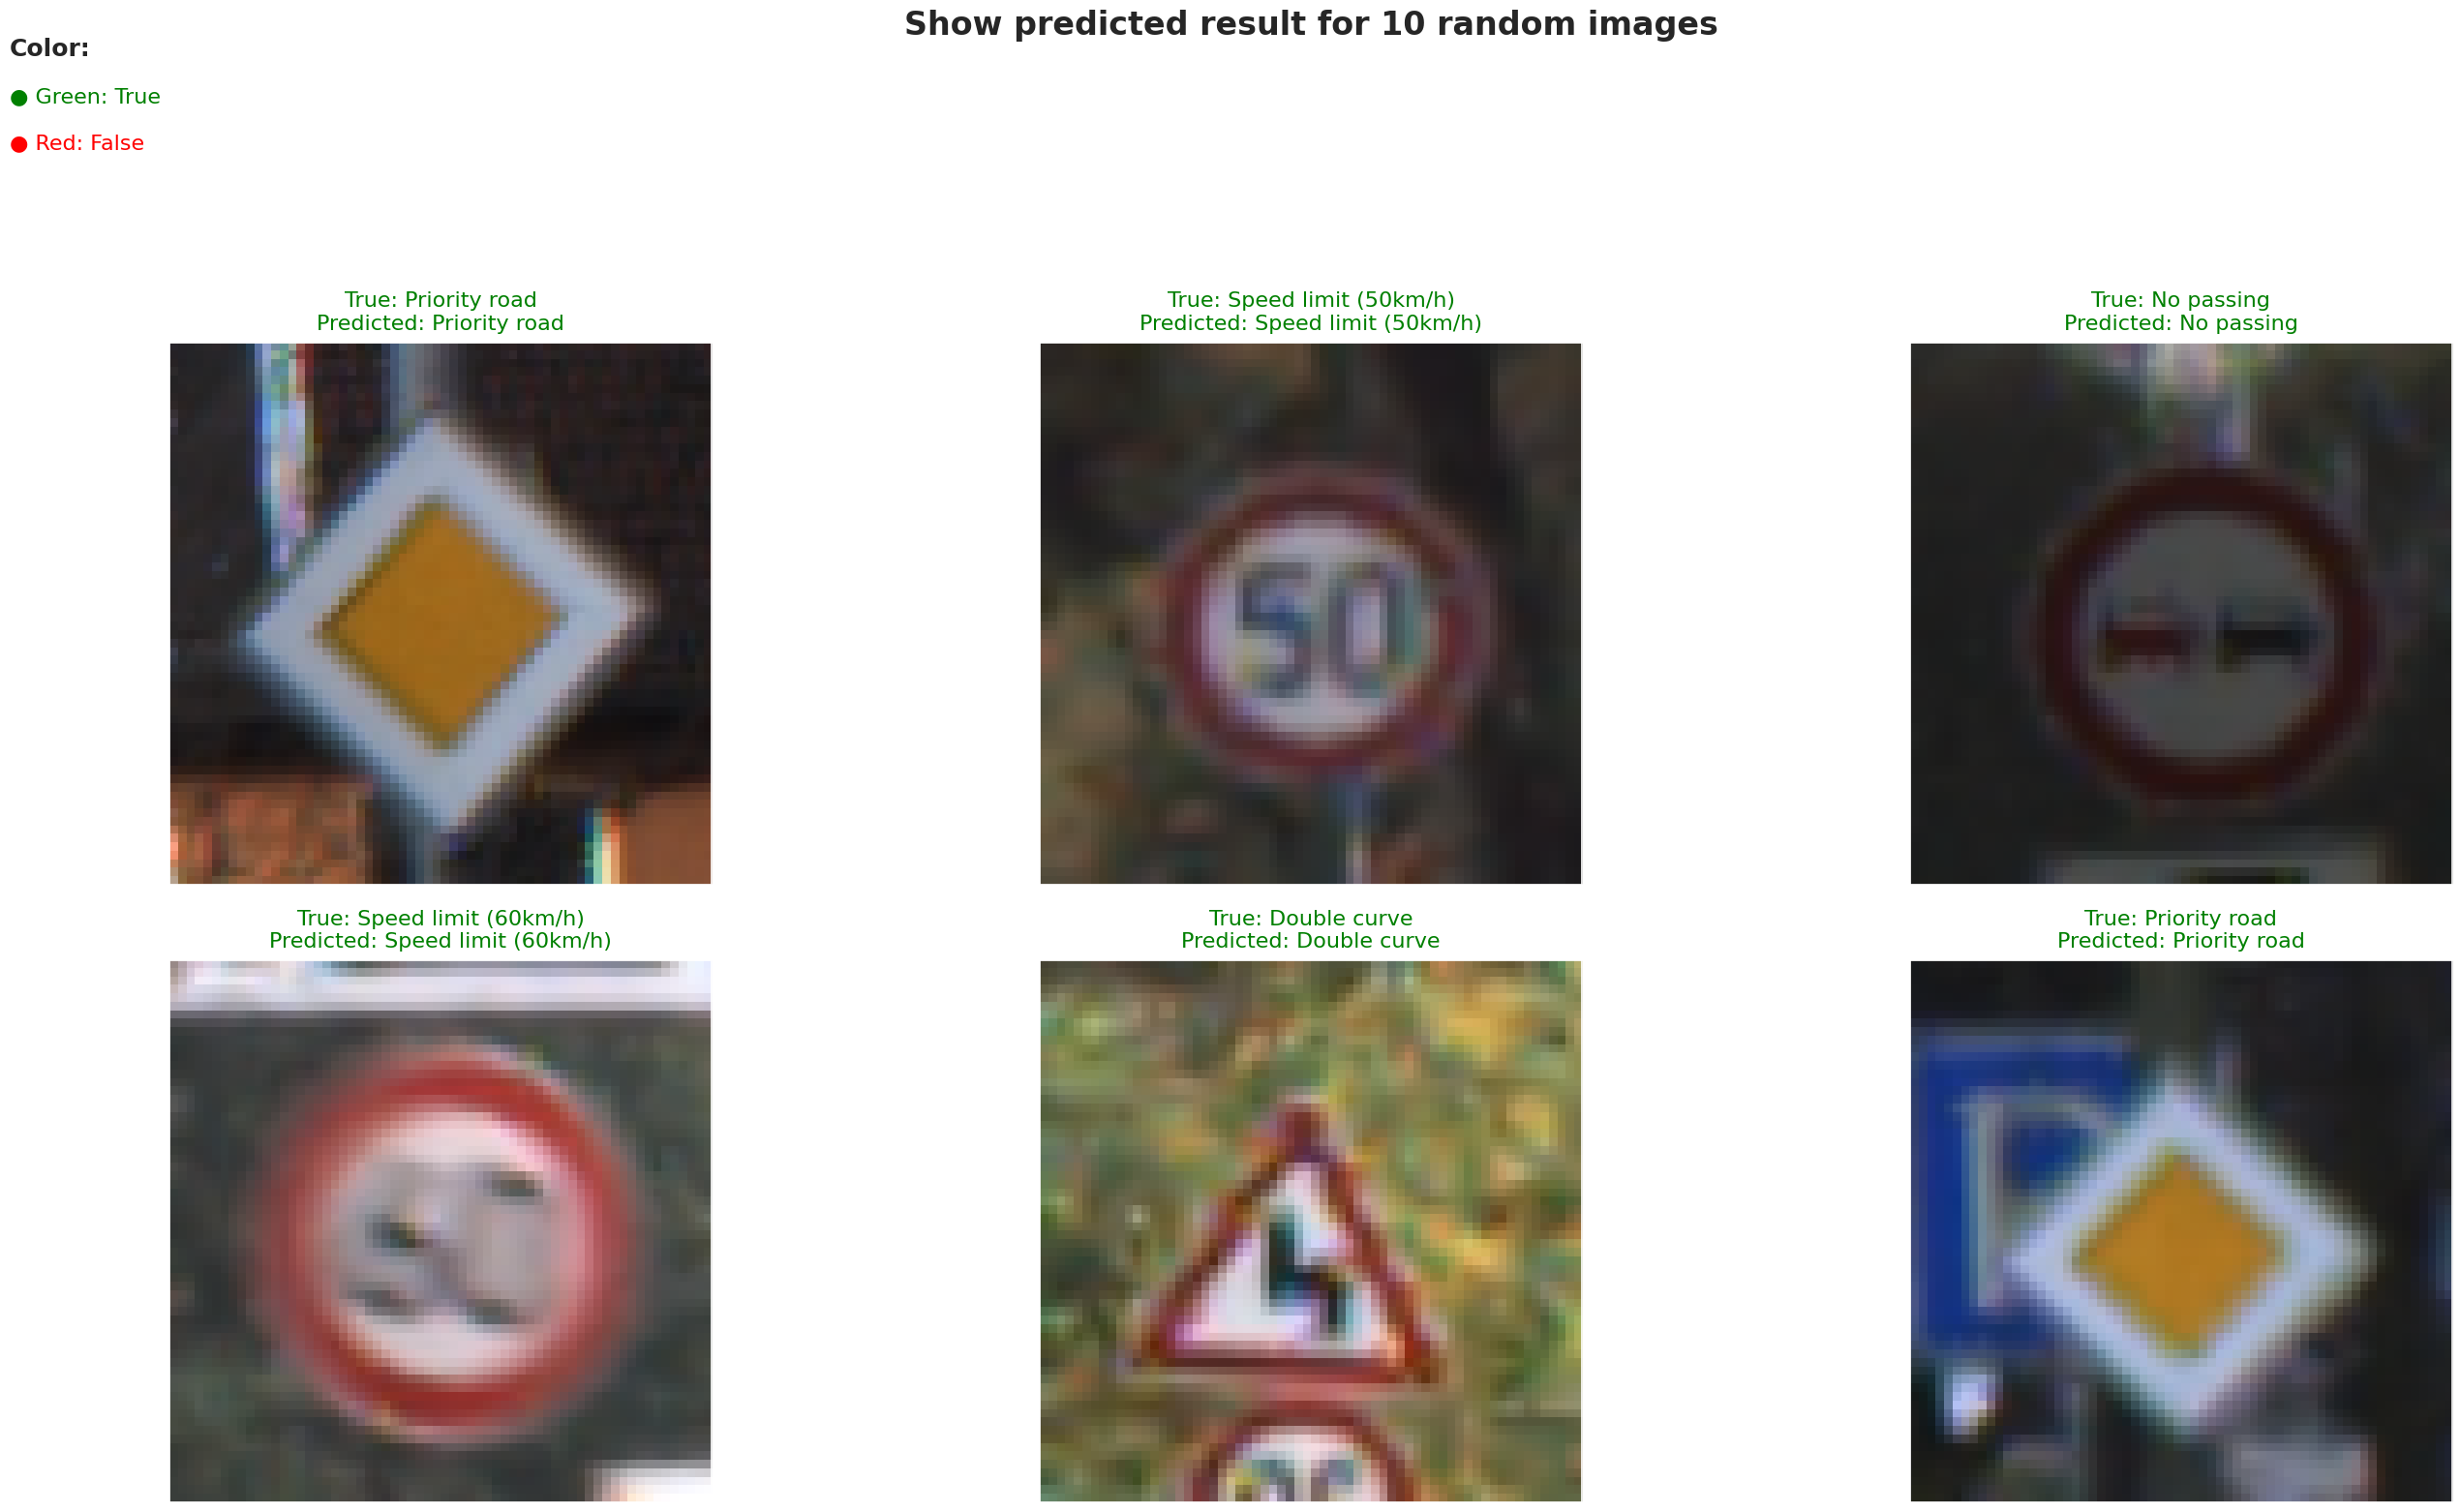

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt

num_images_to_show = 6
random_indices = random.sample(range(len(test_images)), num_images_to_show)

sample_images = test_images[random_indices]
sample_labels = test_labels[random_indices]

predictions = model.predict(sample_images)
predicted_classes = np.argmax(predictions, axis=1)

fig = plt.figure(figsize=(28, 16))

fig.suptitle("Show predicted result for 10 random images", fontsize=24, fontweight='bold')

plt.figtext(0.02, 0.95, "Color:", fontsize=18, weight='bold', ha='left')
plt.figtext(0.02, 0.92, "● Green: True", color="green", fontsize=16, ha='left')
plt.figtext(0.02, 0.89, "● Red: False", color="red", fontsize=16, ha='left')

for i in range(num_images_to_show):
    ax = plt.subplot(2, 3, i + 1)

    plt.imshow(sample_images[i])
    ax.set_xticks([])
    ax.set_yticks([])

    true_label_name = classes[sample_labels[i]]
    predicted_label_name = classes[predicted_classes[i]]

    is_correct = (sample_labels[i] == predicted_classes[i])
    title_color = 'green' if is_correct else 'red'

    ax.set_title(
        f"True: {true_label_name}\nPredicted: {predicted_label_name}",
        color=title_color,
        fontsize=16,
        pad=10
    )

plt.tight_layout(rect=[0, 0, 1, 0.85])

plt.show()